# Results Loader and Plots Comparison for all Models

In [1]:
import re
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd

from config.config import Config
from src.plots import plot_forecast_diagnostics, plot_forecast_next_h, plot_test_overlay_h1, prep_h1_overlay, \
    prep_h_overlay
from src.utils import set_seed

In [2]:
cfg = Config(Path("../config/config.yaml"))
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
rng = set_seed(SEED)

OUT_DIR = Path(cfg.data.processed_dir)
FIG_DIR = Path(cfg.data.fig_dir)

2025-08-27 16:57:09,775 - INFO - src.utils - Global random seed set to 42


In [3]:
def _exp_name_from_metrics(path: Path) -> str:
    m = re.match(r"metrics_test_(.+)\.csv$", path.name)
    return m.group(1) if m else path.stem

def load_results_from_dir(out_dir: Path) -> List[Dict]:
    metrics_files = sorted(out_dir.glob("metrics_test_*.csv"))
    if not metrics_files:
        raise FileNotFoundError(f"No metrics files found in {out_dir}.")

    results: List[Dict] = []
    for mfile in metrics_files:
        name = _exp_name_from_metrics(mfile)

        metrics_df = pd.read_csv(mfile)
        metrics_row = metrics_df.iloc[0].to_dict()

        npz_path = out_dir / f"preds_{name}.npz"
        test_idx_path = out_dir / f"test_index_{name}.npy"
        y_pred_test = y_pred_last = test_index = None
        if npz_path.exists():
            data = np.load(npz_path, allow_pickle=True)
            y_pred_test = data.get("y_pred_test", None)
            y_pred_last = data.get("y_pred_last", None)
        if test_idx_path.exists():
            test_index = np.load(test_idx_path, allow_pickle=True)

        res = {
            "kind": name,
            "metrics": {"test": metrics_row},
            "paths": {
                "preds_npz": str(npz_path),
                "test_index_npy": str(test_idx_path),
                "metrics_csv": str(mfile),
                "features_csv": str(out_dir / f"features_{name}.csv"),
                "params_csv": str(out_dir / f"best_params_{name}.csv"),
                "model": str(out_dir / f"{name}.pkl"),
            },
            "y_pred_test": y_pred_test,
            "y_pred_last": y_pred_last,
            "test_index": test_index,
        }
        results.append(res)
    return results

results = load_results_from_dir(OUT_DIR)
len(results), [r["kind"] for r in results]

(5, ['linreg', 'linreg_wo_sent', 'mlp', 'random_forest', 'xgboost_cpu'])

In [4]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")

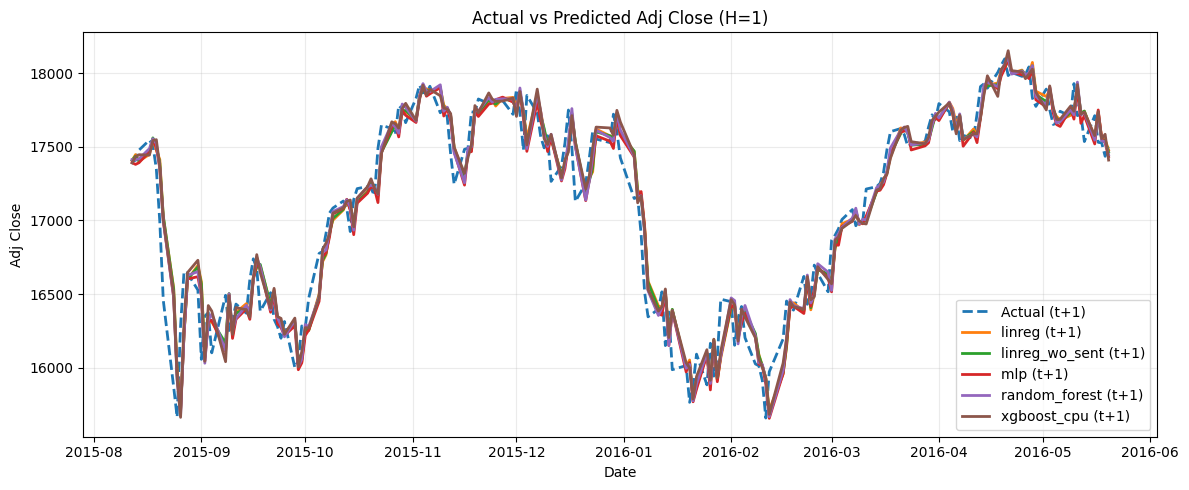

In [5]:
dates_next, actual_next, pred_next_by_model = prep_h1_overlay(df_full, results)
plot_test_overlay_h1(
    dates_next=dates_next,
    actual_next=actual_next,
    pred_next_by_model=pred_next_by_model,
    path=FIG_DIR / "all_actual_vs_predicted_adj_close.png",
)

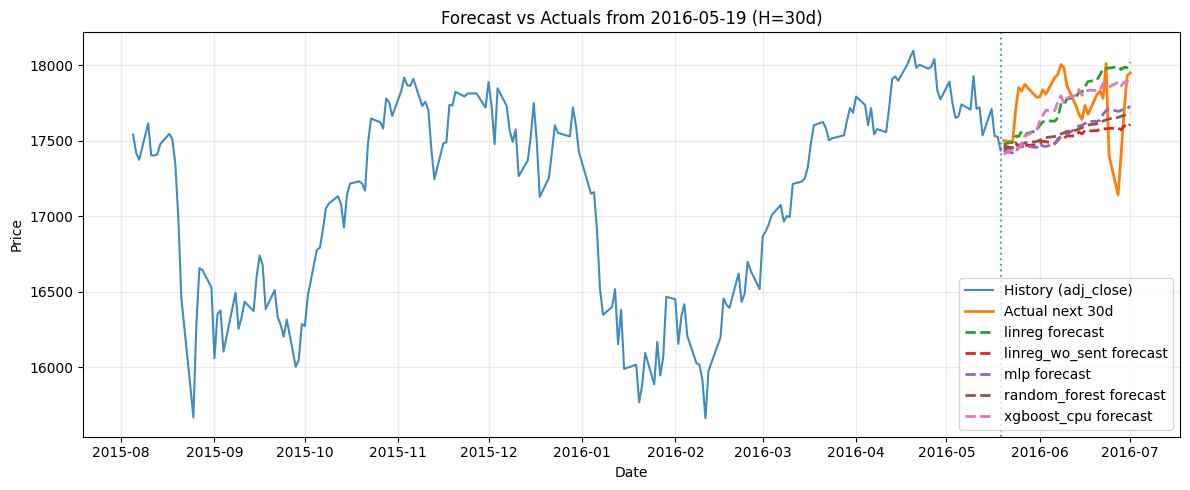

In [6]:
hist_dates, hist_prices, fut_dates, actual_path, anchor_date, paths_by_model = prep_h_overlay(df_full, results, HORIZON)
plot_forecast_next_h(
    hist_dates=hist_dates,
    hist_prices=hist_prices,
    fut_dates=fut_dates,
    forecast_paths_by_model=paths_by_model,
    actual_path=actual_path,
    anchor_date=anchor_date,
    H=HORIZON,
    path=FIG_DIR / "all_forecast.png",
)

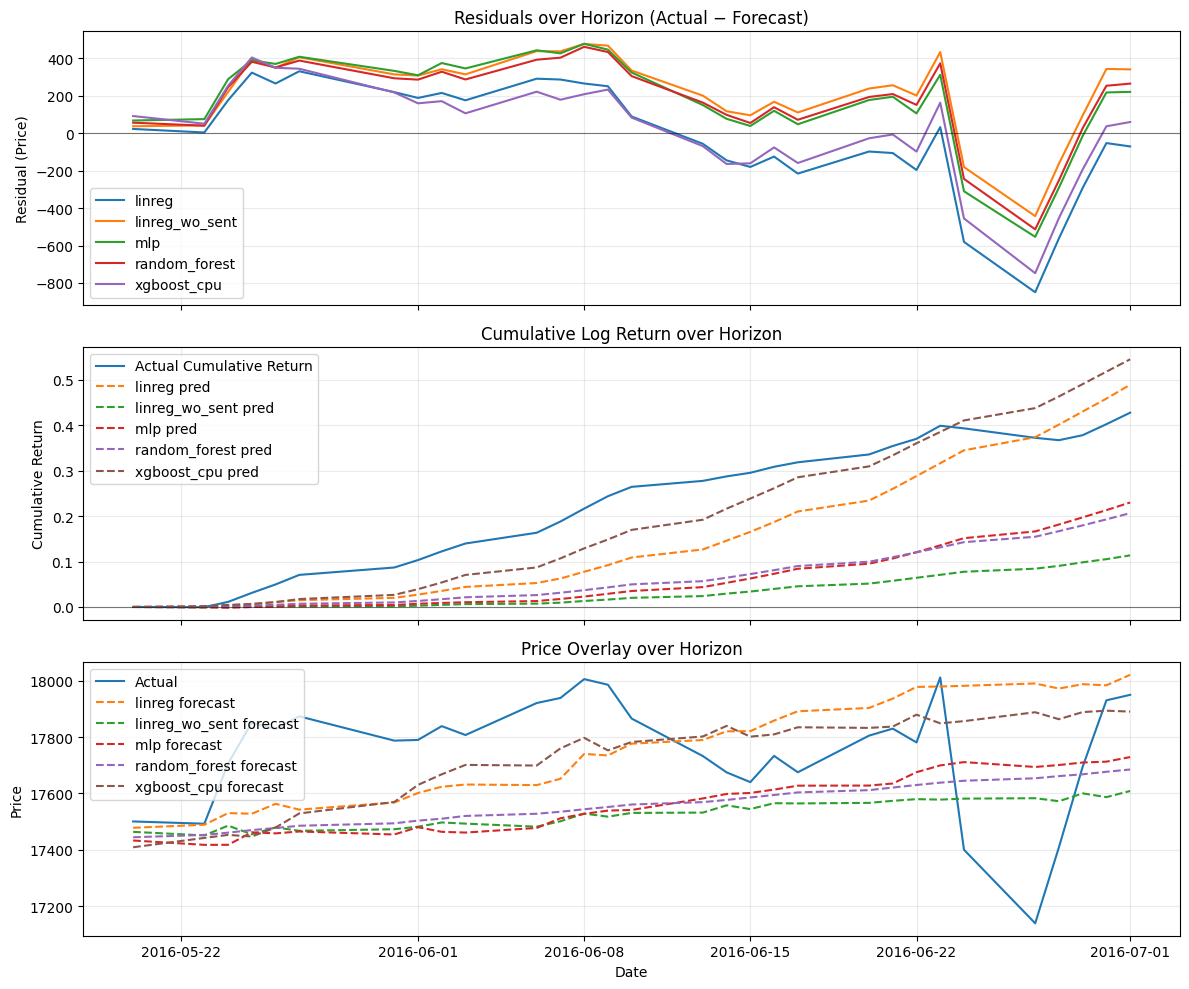

In [7]:
plot_forecast_diagnostics(
    fut_dates=fut_dates,
    actual_path=actual_path,
    forecast_paths_by_model=paths_by_model,
    path=FIG_DIR / "forecast_diagnostics.png",
)